In [1]:
import pandas as pd
import json

input_file = "../merged_cleaned_data.json"
with open(input_file, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(len(df))

2907157


In [2]:
import re

def preprocess_text(text):
    if isinstance(text,str):
        text = text.lower()
        text = text.strip()
        text = re.sub(r"\s+"," ",text)
        text = re.sub(r"[^\w\s]","",text)
    return text

def preprocess_column(df,column_name):
    df[column_name] = df[column_name].apply(preprocess_text)
    return df

df = preprocess_column(df,"title")
df["title"].sample(10)

898963           gri suet kumas runner dikdortgen sehpa boyu
881229     dijital kaymaz yikanabilir modern renkli salon...
294611                                    cam limon sikacagi
1202633                                yari mat deri vernigi
507810     bisiklet saati gercekci vintage dekoratif sus ...
1056428                              arsiv proje kutusu mavi
212231            inox paslanmaz kiyma makinesi aynasi agizi
500316                                 xiaomi play arka lens
1955219                                  siyah detayli yelek
413755     calar kayipsiz ses destegi hafiza karti tasina...
Name: title, dtype: object

In [3]:
from sklearn.preprocessing import LabelEncoder

def mergeCategories(df,columns):
    df["merged_categories"] = df[columns].apply(lambda x: "_".join(x.astype(str)),axis=1)
    return df

df = mergeCategories(df, ["super_category", "category_1", "category_2"])
le = LabelEncoder()
df['merged_categories_le'] = le.fit_transform(df['merged_categories'])

In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def add_tokenized_column(df,text_column='title',token_column='tokenized_title',max_len=30,num_words=3000):
    tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(df[text_column])
    sequences = tokenizer.texts_to_sequences(df[text_column])
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')
    df[token_column] = list(padded_sequences)
    return df, tokenizer


df, tokenizer = add_tokenized_column(df,text_column='title')

In [10]:
from sklearn.model_selection import train_test_split
import numpy as np
padded = df['tokenized_title']
X_train, X_test, y_train, y_test = train_test_split(padded,df['merged_categories_le'],test_size=0.2,random_state=42,stratify=df['merged_categories_le'])
X_train = np.array(X_train.tolist())
X_test = np.array(X_test.tolist())
y_train = np.array(y_train.tolist())
y_test = np.array(y_test.tolist())

In [22]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, GlobalMaxPooling1D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Attention

def build_gru_model(input_length, vocab_size, num_classes, embedding_dim=128,gru_units=64,dropout_rate=0.3):
    input_layer = Input(shape=(input_length,))
    embedding_layer = Embedding(input_dim = vocab_size, output_dim = embedding_dim)(input_layer)
    gru_layer = GRU(gru_units,return_sequences=True)(embedding_layer)
    attention_layer = Attention()([gru_layer, gru_layer])
    
    global_pool = GlobalMaxPooling1D()(attention_layer)
    dropout_layer = Dropout(dropout_rate)(global_pool)
    dense_layer = Dense(64,activation="relu")(dropout_layer)
    output_layer = Dense(num_classes,activation="softmax")(dense_layer)

    model = Model(inputs=input_layer,outputs=output_layer)
    model.compile(optimizer=Adam(learning_rate = 0.0005),loss="sparse_categorical_crossentropy",metrics=["accuracy"])
    return model

In [23]:
model = build_gru_model(input_length=30,vocab_size = 3000,num_classes=len(df['merged_categories_le'].unique()))
from tensorflow.keras.callbacks import EarlyStopping

history = model.fit(
    X_train,y_train,
    validation_data = (X_test,y_test),
    epochs=10,
    batch_size = 64,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
)

Epoch 1/10
36340/36340 [==============================] - 229s 6ms/step - loss: 2.2450 - accuracy: 0.5118 - val_loss: 1.5997 - val_accuracy: 0.6363
Epoch 2/10
36340/36340 [==============================] - 240s 7ms/step - loss: 1.6130 - accuracy: 0.6332 - val_loss: 1.4508 - val_accuracy: 0.6625
Epoch 3/10
36340/36340 [==============================] - 222s 6ms/step - loss: 1.5062 - accuracy: 0.6533 - val_loss: 1.3842 - val_accuracy: 0.6758
Epoch 4/10
36340/36340 [==============================] - 225s 6ms/step - loss: 1.4478 - accuracy: 0.6650 - val_loss: 1.3471 - val_accuracy: 0.6843
Epoch 5/10
36340/36340 [==============================] - 235s 6ms/step - loss: 1.4086 - accuracy: 0.6729 - val_loss: 1.3215 - val_accuracy: 0.6892
Epoch 6/10
36340/36340 [==============================] - 224s 6ms/step - loss: 1.3798 - accuracy: 0.6789 - val_loss: 1.2986 - val_accuracy: 0.6944
Epoch 7/10
36340/36340 [==============================] - 227s 6ms/step - loss: 1.3581 - accuracy: 0.6833 - val_

In [24]:
def predict_product(product_name, tokenizer, labelencoder):

    product_name = product_name.lower().strip()
    sequence = tokenizer.texts_to_sequences([product_name])
    padded_sequence = pad_sequences(sequence, maxlen=30, padding="post")
    pred_probs = model.predict(padded_sequence)
    pred_class = np.argmax(pred_probs, axis=1)

    predicted_category = labelencoder.inverse_transform(pred_class)

    return predicted_category[0]


test_products = ["sleepy bebek bezi çok rahat ve sızdırmaz", "bebek bezi sleepy", "ultra güçlü bebek bezi sızdırmayan sleepy"]
print("\nÖzel Ürün Adları İçin Tahminler:")
for product in test_products:
    predicted_label = predict_product(product, tokenizer, le)
    print(f"Ürün: '{product}'")
    print(f"Tahmin Edilen Etiket: {predicted_label}\n")


Özel Ürün Adları İçin Tahminler:
1/1 [==============================] - 0s 213ms/step
Ürün: 'sleepy bebek bezi çok rahat ve sızdırmaz'
Tahmin Edilen Etiket: supermarket_bebek bezi islak mendil_bebek bezi

1/1 [==============================] - 0s 15ms/step
Ürün: 'bebek bezi sleepy'
Tahmin Edilen Etiket: supermarket_bebek bezi islak mendil_bebek bezi

1/1 [==============================] - 0s 13ms/step
Ürün: 'ultra güçlü bebek bezi sızdırmayan sleepy'
Tahmin Edilen Etiket: supermarket_bebek bezi islak mendil_bebek bezi



In [25]:
test_products = ["Iphone 15 telefon 256gb", "Iphone 15 telefon kılıfı", "Iphone 15 uyumlu airpods"]
print("\nÖzel Ürün Adları İçin Tahminler:")
for product in test_products:
    predicted_label = predict_product(product, tokenizer, le)
    print(f"Ürün: '{product}'")
    print(f"Tahmin Edilen Etiket: {predicted_label}\n")


Özel Ürün Adları İçin Tahminler:
1/1 [==============================] - 0s 22ms/step
Ürün: 'Iphone 15 telefon 256gb'
Tahmin Edilen Etiket: elektronik_telefon_telsiz masaustu telefonlar

1/1 [==============================] - 0s 13ms/step
Ürün: 'Iphone 15 telefon kılıfı'
Tahmin Edilen Etiket: elektronik_telefon_telsiz masaustu telefonlar

1/1 [==============================] - 0s 14ms/step
Ürün: 'Iphone 15 uyumlu airpods'
Tahmin Edilen Etiket: elektronik_telefon_cep telefonu aksesuarlari



In [36]:
test_products = ["Kadın kot pantolon", "Dizüstü laptop nvidia 3050 ekran kartlı", "bebek puseti","kalemtraş","araba torpido tutacağı"]
print("\nÖzel Ürün Adları İçin Tahminler:")
for product in test_products:
    predicted_label = predict_product(product, tokenizer, le)
    print(f"Ürün: '{product}'")
    print(f"Tahmin Edilen Etiket: {predicted_label}\n")


Özel Ürün Adları İçin Tahminler:
1/1 [==============================] - 0s 15ms/step
Ürün: 'Kadın kot pantolon'
Tahmin Edilen Etiket: moda_giyim ayakkabi_kadin

1/1 [==============================] - 0s 14ms/step
Ürün: 'Dizüstü laptop nvidia 3050 ekran kartlı'
Tahmin Edilen Etiket: elektronik_bilgisayar sistemleri ekipmanlari_aksesuarlar

1/1 [==============================] - 0s 16ms/step
Ürün: 'bebek puseti'
Tahmin Edilen Etiket: anne bebek oyuncak_oyuncak_oyuncak bebek aksesuar

1/1 [==============================] - 0s 15ms/step
Ürün: 'kalemtraş'
Tahmin Edilen Etiket: yasam kirtasiye ofis_kirtasiye ofis_ofis okul kirtasiye

1/1 [==============================] - 0s 14ms/step
Ürün: 'araba torpido tutacağı'
Tahmin Edilen Etiket: yapi market bahce oto_oto aksesuar_oto aksesuar urunleri



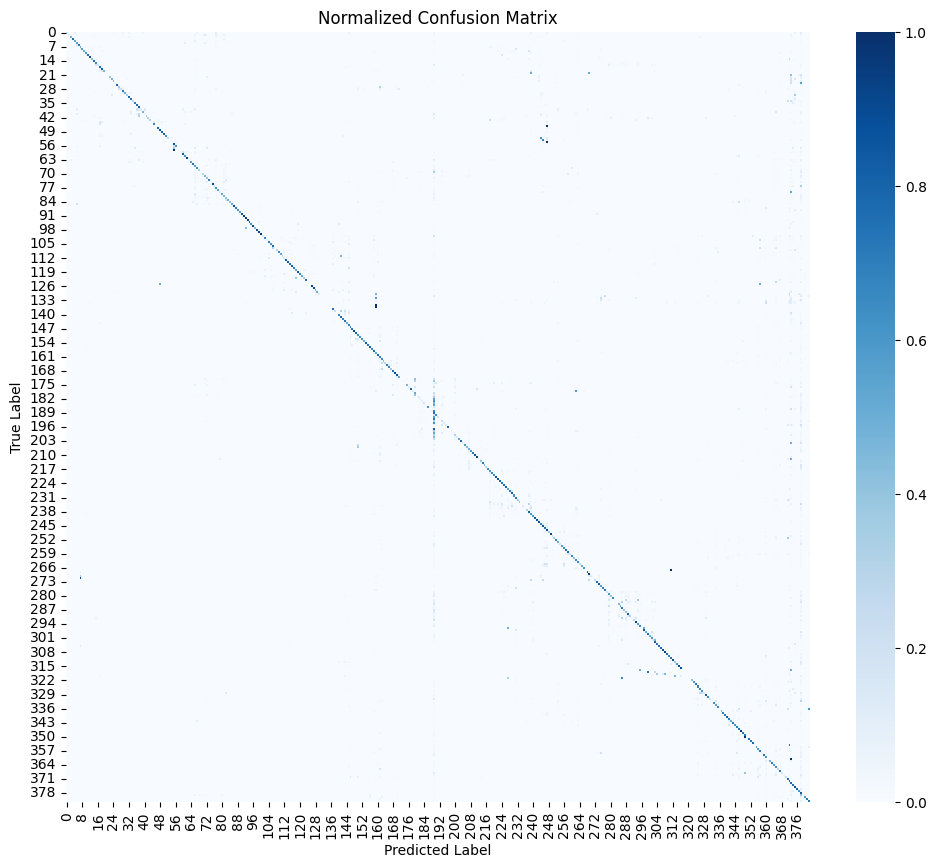

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred, normalize='true')  # normalize ekledik

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues')
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
